<a href="https://colab.research.google.com/github/Sofiosu24/IA_training_classification_realWaste/blob/main/colabs/RealWaste_Modelo_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/realwaste_main/RealWaste"

/content/drive/MyDrive/realwaste_main/RealWaste


In [ ]:
!ls

test  train  validation


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
base_dir = '/content/drive/MyDrive/realwaste_main/RealWaste'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

print("Train:", train_dir)
print("Validation:", validation_dir)
print("Test:", test_dir)

Train: /content/drive/MyDrive/realwaste_main/RealWaste/train
Validation: /content/drive/MyDrive/realwaste_main/RealWaste/validation
Test: /content/drive/MyDrive/realwaste_main/RealWaste/test


In [ ]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 40,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)

val_datagen = ImageDataGenerator(rescale=1./255)


In [ ]:
# Tamaño al que vamos a redimensionar todas las imágenes
target_size = (150, 150)
batch_size = 20

# Generador de entrenamiento
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = target_size,
    batch_size = batch_size,
    class_mode = 'categorical')

# Generador de validación
val_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size = target_size,
    batch_size = batch_size,
    class_mode = 'categorical')

Found 3323 images belonging to 9 classes.
Found 715 images belonging to 9 classes.


Found 3323 images belonging to 9 classes.


<Figure size 640x480 with 0 Axes>

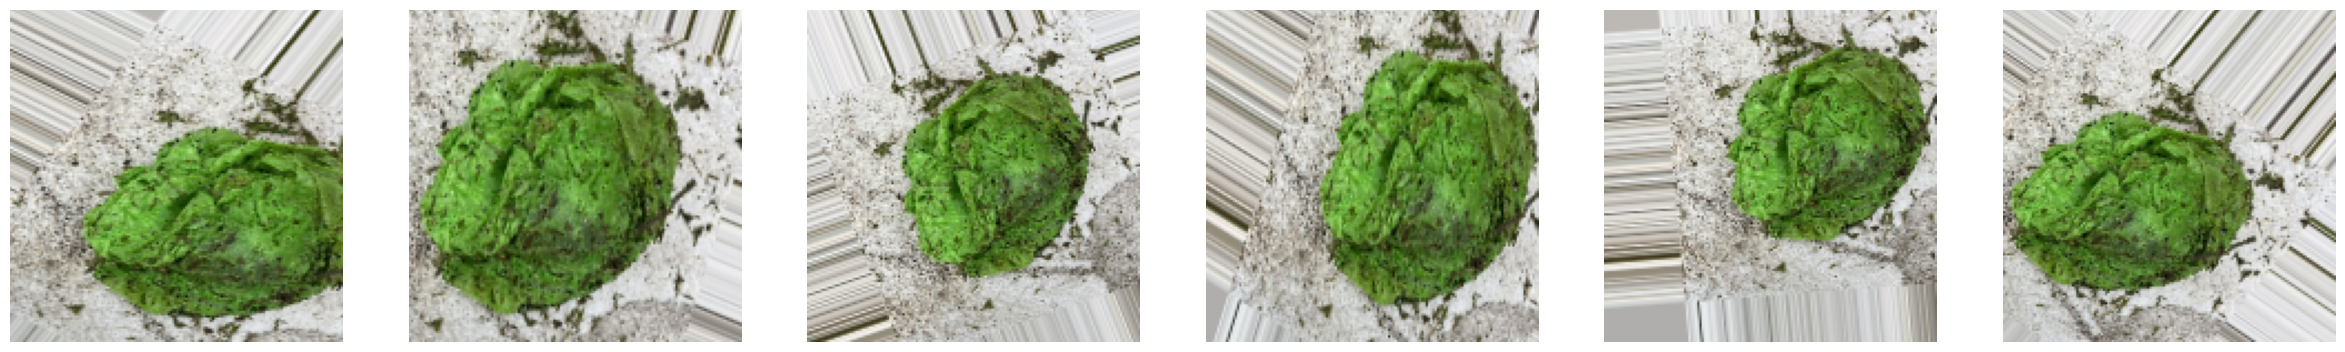

In [ ]:
# Crear un generador temporal con batch_size=1 para visualizar
# Tomamos imágenes de train (que tiene augmentation aplicado)
viz_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = target_size,
    batch_size = 1,
    class_mode = 'categorical')

# Mostrar 6 versiones diferentes de la primera imagen
plt.figure()
f, axarr = plt.subplots(1, 6, figsize=(30, 8))

for i in range(6):
    axarr[i].imshow(train_generator[0][0][0])
    axarr[i].axis('off')

plt.show()


Found 3323 images belonging to 9 classes.
(15, 150, 150, 3)
[[0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]]


<Figure size 640x480 with 0 Axes>

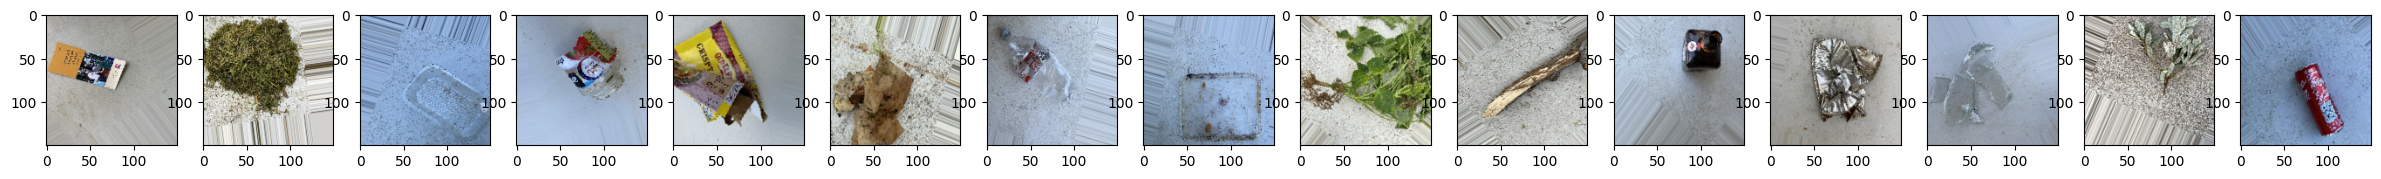

In [ ]:
viz_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (150, 150),
    batch_size = 15,
    class_mode ='categorical')

images , labels = viz_generator[0]

print(images.shape)
print(labels)


plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

In [ ]:
os.makedirs('/content/drive/MyDrive/realwaste_main/checkpoints', exist_ok=True)

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras.metrics import Precision, Recall, F1Score, CategoricalAccuracy

model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(9, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457,225 (13.19 MB)

 Trainable params: 3,457,225 (13.19 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=1e-3),
    metrics=[
        CategoricalAccuracy(name='acc'),
        Precision(name='precision'),
        Recall(name='recall'),
        F1Score(average='macro', name='f1_score')
    ]
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

# Path del checkpoint de v3
checkpoint_path = '/content/drive/MyDrive/realwaste_main/checkpoints/best_model_v3.keras'

checkpoint_best = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,
    save_freq='epoch',
    monitor='val_acc',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_acc',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

cls = train_generator.classes
weights = compute_class_weight('balanced', classes=np.unique(cls), y=cls)
class_weight = dict(enumerate(weights))
print(class_weight)

{0: np.float64(1.1466528640441684), 1: np.float64(1.286488579171506), 2: np.float64(1.2558578987150415), 3: np.float64(0.6676712879244525), 4: np.float64(1.067116249197174), 5: np.float64(1.0549206349206348), 6: np.float64(0.5733264320220842), 7: np.float64(1.6631631631631631), 8: np.float64(1.2105646630236795)}


In [ ]:
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weight,
    callbacks=[checkpoint_best, early_stop])

Epoch 1/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - acc: 0.5625 - f1_score: 0.5422 - loss: 1.1754 - precision: 0.6836 - recall: 0.3969
Epoch 1: val_acc did not improve from 0.41538
167/167 ━━━━━━━━━━━━━━━━━━━━ 56s 311ms/step - acc: 0.5790 - f1_score: 0.5676 - loss: 1.1352 - precision: 0.7086 - recall: 0.4216 - val_acc: 0.2713 - val_f1_score: 0.2567 - val_loss: 2.8471 - val_precision: 0.3011 - val_recall: 0.1832
Epoch 2/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - acc: 0.5890 - f1_score: 0.5771 - loss: 1.0972 - precision: 0.7287 - recall: 0.4341
Epoch 2: val_acc did not improve from 0.41538
167/167 ━━━━━━━━━━━━━━━━━━━━ 47s 281ms/step - acc: 0.5937 - f1_score: 0.5829 - loss: 1.1058 - precision: 0.7224 - recall: 0.4261 - val_acc: 0.3650 - val_f1_score: 0.3696 - val_loss: 1.8968 - val_precision: 0.4528 - val_recall: 0.2615
Epoch 3/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - acc: 0.6242 - f1_score: 0.6134 - loss: 1.0287 - precision: 0.7344 - recall: 0.4813
Epoch 3: val_acc did no

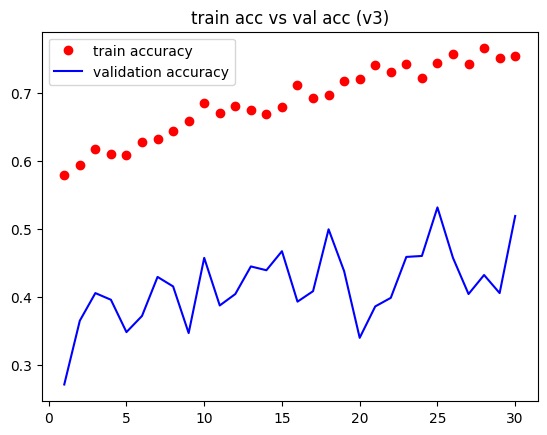

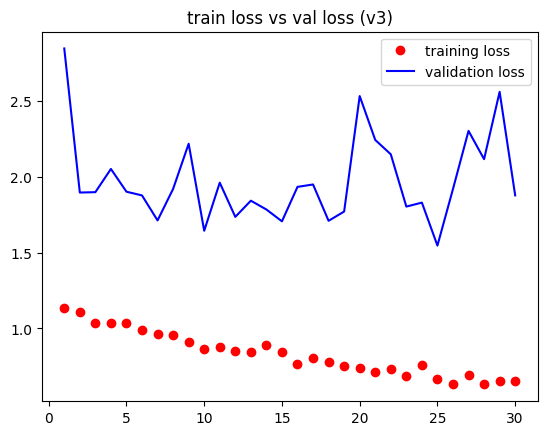

In [ ]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, 'ro', label='train accuracy')
plt.plot(epochs, val_acc, 'b', label='validation accuracy')
plt.title('train acc vs val acc (v3)')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'ro', label='training loss')
plt.plot(epochs, val_loss, 'b', label='validation loss')
plt.title('train loss vs val loss (v3)')
plt.legend()

plt.show()

In [ ]:
from tensorflow.keras.models import load_model

# Cargar el mejor modelo guardado por el checkpoint v3
model = load_model('/content/drive/MyDrive/realwaste_main/checkpoints/best_model_v3.keras')

Found 715 images belonging to 9 classes.
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step


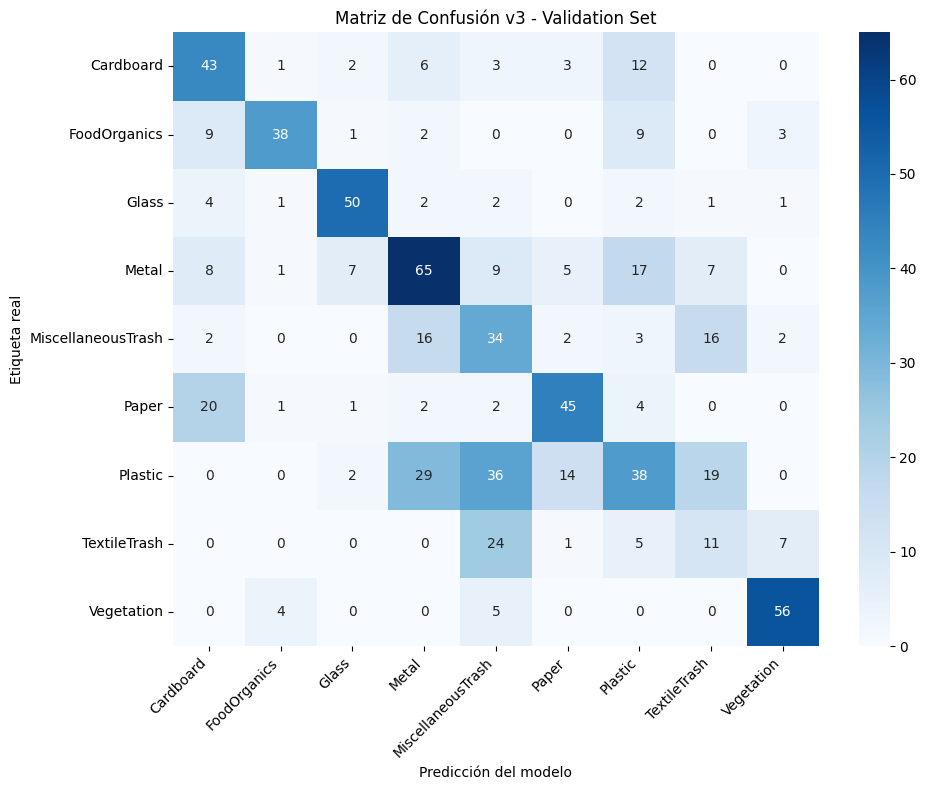

                    precision    recall  f1-score   support

         Cardboard       0.50      0.61      0.55        70
      FoodOrganics       0.83      0.61      0.70        62
             Glass       0.79      0.79      0.79        63
             Metal       0.53      0.55      0.54       119
MiscellaneousTrash       0.30      0.45      0.36        75
             Paper       0.64      0.60      0.62        75
           Plastic       0.42      0.28      0.33       138
      TextileTrash       0.20      0.23      0.22        48
        Vegetation       0.81      0.86      0.84        65

          accuracy                           0.53       715
         macro avg       0.56      0.55      0.55       715
      weighted avg       0.55      0.53      0.53       715



In [ ]:
# Generator de evaluación con shuffle=False
eval_val_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='categorical',
    shuffle=False
)

# Predicciones
predictions = model.predict(eval_val_generator)
classes_x = np.argmax(predictions, axis=1)

# Etiquetas verdaderas
val_labels = eval_val_generator.classes

# Matriz de confusión
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(val_labels, classes_x)

# Nombres de clases
class_names = list(eval_val_generator.class_indices.keys())

# Visualizar
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción del modelo')
plt.ylabel('Etiqueta real')
plt.title('Matriz de Confusión v3 - Validation Set')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification report
from sklearn.metrics import classification_report
print(classification_report(val_labels, classes_x, target_names=class_names))

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/realwaste_main/checkpoints/best_model_v3.keras')

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='categorical',
    shuffle=False)

test_loss, test_acc = model.evaluate(test_generator)
print('\ntest acc:', test_acc)
print('test loss:', test_loss)

Found 714 images belonging to 9 classes.
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 669ms/step - acc: 0.4916 - f1_score: 0.4844 - loss: 1.8879 - precision: 0.5543 - recall: 0.4216


ValueError: too many values to unpack (expected 2)

In [ ]:
results = model.evaluate(test_generator)
test_loss = results[0]   # loss siempre es el primero
test_acc = results[1]    # acc es el segundo
print('\ntest acc:', test_acc)
print('test loss:', test_loss)

36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 553ms/step - acc: 0.4916 - f1_score: 0.4844 - loss: 1.8879 - precision: 0.5543 - recall: 0.4216

test acc: 0.49159663915634155
test loss: 1.887896180152893


In [ ]:
# Reporte detallado por clase
predictions = model.predict(test_generator)
classes_x = np.argmax(predictions, axis=1)
test_labels = test_generator.classes

from sklearn.metrics import classification_report
print(classification_report(test_labels, classes_x,
      target_names=list(test_generator.class_indices.keys())))

36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 464ms/step
                    precision    recall  f1-score   support

         Cardboard       0.58      0.70      0.63        69
      FoodOrganics       0.64      0.44      0.52        62
             Glass       0.35      0.25      0.29        63
             Metal       0.42      0.27      0.33       118
MiscellaneousTrash       0.34      0.54      0.42        74
             Paper       0.67      0.83      0.74        75
           Plastic       0.44      0.46      0.45       139
      TextileTrash       0.21      0.19      0.20        48
        Vegetation       0.75      0.80      0.77        66

          accuracy                           0.49       714
         macro avg       0.49      0.50      0.48       714
      weighted avg       0.49      0.49      0.48       714

